# Dit is een testbook

In [6]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


# 1. Introductie: Waarom goniometrie?

•	Doel: Motiveer het onderwerp vanuit realiteit (bijv. dag-nacht-cyclus, seizoenen, geluidsgolven, hartslag).
•	Simulatie: Een schommelende slinger of een punt op een draaiende cirkel gekoppeld aan een golf.
•	Didactiek: Laat leerlingen voorspellen wat er gebeurt voordat je het toont.
•	Afbeelding: Realtime animatie van een sinusgolf die wordt gegenereerd door een draaiend punt op een cirkel (eenheidscirkel).

# 2. Graden vs. Radialen

## 2.1 Verband tussen graden en radialen

Een cirkel is gedefinieerd als 360°. De omtrek van een cirkel is beschreven met:  
\[
C = 2\pi r
\]

Als je de booglengte van een deel van een cirkel wilt berekenen, doe je dat met een verhouding:  
\[
C = \left( \frac{\theta}{360^\circ} \right) \cdot 2\pi r
\]

Voor een halve cirkel (\( \theta = 180^\circ \)) geeft dat een factor van \( \frac{1}{2} \).  
Voor een kwart cirkel (\( \theta = 90^\circ \)) is dat \( \frac{1}{4} \).

Bij een cirkel met straal \( r = 1 \) (de **eenheidscirkel**) kunnen we booglengtes direct uitdrukken in radialen. Hier is een overzicht:

| \( \theta \) (°) | \( C \) (rad)         |
|------------------|-----------------------|
| 0°               | \( 0 \)               |
| 30°              | \( \frac{1}{6} \pi \) |
| 45°              | \( \frac{1}{4} \pi \) |
| 60°              | \( \frac{1}{3} \pi \) |
| 90°              | \( \frac{1}{2} \pi \) |
| 180°             | \( \pi \)             |
| 270°             | \( \frac{3}{2} \pi \) |
| 360°             | \( 2\pi \)            |

---



Stel dat je op een eenheidscirkel loopt (een cirkel met \( r = 1 \)), dan kun je je positie op de cirkel beschrijven met:

- de afgelegde **hoek** \( \theta \) in **graden** (°),  
- óf de afgelegde **booglengte** \( C \) in **radialen** (rad).

De **radiaal** is dus een alternatieve eenheid voor de graad, net zoals je lengte kunt uitdrukken in zowel kilometers als mijlen.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact
from matplotlib.lines import Line2D




# Updatefunctie
def update(theta_deg):
    
    # Voorbereiding van figuur en plots
    plt.figure(figsize=(6, 6))
    plt.xlim(-1.2, 1.2)
    plt.ylim(-1.2, 1.2)
    plt.title("Eenheidscirkel met hoek θ")
    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)

    # Eenheidscirkel
    circle_theta = np.linspace(0, 2 * np.pi, 1000)
    circle_x = np.cos(circle_theta)
    circle_y = np.sin(circle_theta)
    plt.plot(circle_x, circle_y, 'lightgray')


    # Lijnen en objecten die we gaan updaten
    line_OP, = plt.plot([], [], 'r-', linewidth=2)
    arc_line, = plt.plot([], [], 'b--', linewidth=2)
    angle_arc, = plt.plot([], [], 'g-', linewidth=1.5)
    point_P, = plt.plot([], [], 'ro')

    # Teksten die we updaten
    text_P = plt.text(0, 0, '', fontsize=12, color='red')
    text_deg = plt.text(0, 0, '', fontsize=10, color='green', ha='center')
    text_rad = plt.text(0, 0, '', fontsize=10, color='blue', ha='center')

    # Extra vaste labels
    plt.text(1.05, 0, 'x', fontsize=12)
    plt.text(0, 1.05, 'y', fontsize=12)
    plt.text(-0.1, -0.1, 'O', fontsize=12)


    theta_rad = np.radians(theta_deg)
    x = np.cos(theta_rad)
    y = np.sin(theta_rad)

    # Update lijn OP
    line_OP.set_data([0, x], [0, y])

    # Update boog
    arc_theta = np.linspace(0, theta_rad, 300)
    arc_line.set_data(np.cos(arc_theta), np.sin(arc_theta))

    # Hoekboogje
    angle_arc_theta = np.linspace(0, theta_rad, 100)
    angle_arc_r = 0.3
    angle_arc.set_data(angle_arc_r * np.cos(angle_arc_theta),
                       angle_arc_r * np.sin(angle_arc_theta))

    # Punt P
    point_P.set_data([x], [y])
    text_P.set_position((x + 0.05 * np.sign(x), y + 0.05 * np.sign(y)))
    text_P.set_text("P")

    # Hoeklabels
    text_deg.set_position((0.35 * np.cos(theta_rad / 2), 0.35 * np.sin(theta_rad / 2)))
    text_deg.set_text(f"θ = {theta_deg}°")

    text_rad.set_position((0.5 * np.cos(theta_rad / 2), 0.5 * np.sin(theta_rad / 2)))
    text_rad.set_text(f"{round(theta_rad, 2)} rad")

    # Titel
    plt.title(f"θ = {theta_deg}° = {round(theta_rad, 2)} rad")

 

# Interactieve slider
interact(update, theta_deg=IntSlider(min=0, max=360, step=1, value=0, description="Hoek θ (°)"));

interactive(children=(IntSlider(value=0, description='Hoek θ (°)', max=360), Output()), _dom_classes=('widget-…

## 2.2 Omrekenen van graden en radialen

Rekenen met graden en radialen:
We hebben dus gezien dat je radialen kan berekenen met graden C=(θ/(360°))2π.  Omdat het eigenlijk een verhouding is kunnen we ook zeggen dat;
θ_rad=(π/(180°)) θ_deg
En de verhouding kan je ook omdraaien; 
θ_deg=((180°)/π) θ_rad
Dus 1 rad zou dan gelijk moeten zijn aan 57,3°. Mochten verhoudingen toch een beetje lastig zijn kan je ook gebruik maken van een verhoudingstabel;
Hoek 	Hele cirkel	Cirkel gedeelte
θ (graden)	360°	90°
θ (radialen)	2π	θ

Je kan de gewenste hoek o.a. met een kruistabel berekenen;
360°∙θ=2π∙90° wat θ=1/4 π geeft.


# 3. De eenheidscirkel en goniometrische functies

Als we een kijkje nemen op de eenheidscirkel kun je dus voor een bepaalde hoek θ op een punt (positie) P(x,y) staan. Dan kan je je voorstellen dat het interessant is om te berekenen met de hoek θ waar je staat op de eenheidscirkel. Maar hoe kunnen we het x-coordinaat en y-coordinaat beschrijven als functie van de hoek θ? Als we kijken in het onderstaande figuur zien we dat de afstand tussen P en de x-as het y-coördinaat voorstelt en de afstand tussen P en de y-as het x-coördinaat voorstelt. Dit vormt een rechte driehoek waar we SOS, CAS, TOA op kunnen loslaten;
SOS; sin⁡(θ)=y/1
CAS; cos⁡(θ)=x/1
TOA; tan⁡(θ)=y/x
Wat we dus hebben geleerd is dat het punt P(x,y) berekent kan worden met 
x=cos⁡(θ)
y=sin⁡(θ)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import IntSlider, interact
import matplotlib.gridspec as gridspec

def plot_figure(theta):
    # Zet figuur opnieuw op bij elke update
    fig = plt.figure(figsize=(10, 12))
    gs = gridspec.GridSpec(3, 1, height_ratios=[2, 1, 1])
    ax_circle = plt.subplot(gs[0])
    ax_cos = plt.subplot(gs[1])
    ax_sin = plt.subplot(gs[2])
    plt.subplots_adjust(left=0.1, bottom=0.15, hspace=0.4)

    # Eenheidscirkel
    circle = plt.Circle((0, 0), 1, color='purple', fill=False)
    ax_circle.add_artist(circle)
    ax_circle.set_xlim(-1.2, 1.2)
    ax_circle.set_ylim(-1.2, 1.2)
    ax_circle.set_aspect('equal')
    ax_circle.grid(True)
    ax_circle.set_title("Eenheidscirkel en Rechthoekige Driehoek")

    # Assen door oorsprong
    ax_circle.spines['left'].set_position('zero')
    ax_circle.spines['bottom'].set_position('zero')
    ax_circle.spines['right'].set_color('none')
    ax_circle.spines['top'].set_color('none')
    ax_circle.xaxis.set_ticks([-1, 1])
    ax_circle.yaxis.set_ticks([-1, 1])
    ax_circle.text(1.05, 0, 'x', fontsize=12)
    ax_circle.text(0, 1.05, 'y', fontsize=12)
    ax_circle.text(-0.15, -0.15, 'O', fontsize=12)

    # Hoek en coördinaten
    theta_rad = np.deg2rad(theta)
    x = np.cos(theta_rad)
    y = np.sin(theta_rad)

    # Rechthoekige driehoek
    ax_circle.plot([0, x], [0, y], color='black')  # Hypotenusa
    ax_circle.plot([0, x], [0, 0], color='red')     # x-component
    ax_circle.plot([x, x], [0, y], color='blue')    # y-component
    ax_circle.plot(x, y, 'ko')                      # Punt P
    ax_circle.text(x + 0.05, y, f'P(', fontsize=10)
    ax_circle.text(x + 0.15, y, f'{x:.2f}', fontsize=10, color='red')
    ax_circle.text(x + 0.35, y, f', {y:.2f})', fontsize=10, color='blue')

    # Hoekboog
    arc_radius = 0.25
    arc_angle = np.linspace(0, theta_rad, 100)
    arc_x = arc_radius * np.cos(arc_angle)
    arc_y = arc_radius * np.sin(arc_angle)
    ax_circle.plot(arc_x, arc_y, 'gray')
    ax_circle.text(
        arc_radius * np.cos(theta_rad / 2),
        arc_radius * np.sin(theta_rad / 2),
        f'θ = {int(theta)}°',
        fontsize=10
    )

    # Cos/Sin-grafieken
    theta_deg = np.linspace(0, 360, 1000)
    theta_rad_all = np.deg2rad(theta_deg)
    cos_vals = np.cos(theta_rad_all)
    sin_vals = np.sin(theta_rad_all)

    ax_cos.plot(theta_deg, cos_vals, label='x(θ) = cos(θ)', color='red')
    ax_cos.plot(theta, np.cos(theta_rad), 'ko')
    ax_cos.text(theta + 5, np.cos(theta_rad), f'({int(theta)}°, {np.cos(theta_rad):.3f})', fontsize=9)

    ax_sin.plot(theta_deg, sin_vals, label='y(θ) = sin(θ)', color='blue')
    ax_sin.plot(theta, np.sin(theta_rad), 'ko')
    ax_sin.text(theta + 5, np.sin(theta_rad), f'({int(theta)}°, {np.sin(theta_rad):.3f})', fontsize=9)

    for ax, ylabel in zip([ax_cos, ax_sin], ['cos(θ)', 'sin(θ)']):
        ax.set_xlim(0, 360)
        ax.set_ylim(-1.2, 1.2)
        ax.grid(True)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_ylabel(ylabel)
        ax.set_xlabel('θ (graden)')
        ax.spines['left'].set_position('zero')
        ax.spines['bottom'].set_position('zero')
        ax.spines['right'].set_color('none')
        ax.spines['top'].set_color('none')
        ax.set_xticks([0, 180, 360])
        ax.set_yticks([-1, 1])
        ax.legend()

    plt.show()

# Interactieve slider
interact(plot_figure, theta=IntSlider(min=0, max=360, step=1, value=60, description='θ (graden)'));


interactive(children=(IntSlider(value=60, description='θ (graden)', max=360), Output()), _dom_classes=('widget…

Hierin is de rode en blauwe functie:
x=cos⁡(θ)
y=sin⁡(θ)
Als we nou met onze vinger de eenheid cirkel volgen dan merken we dat de grafiek overeen komt met onze verwachting
Kwartcirkel	Coördinaat P(x,y)
1e kwadrant	(+,+)
2e kwadrant	(-,+)
3e kwadrant	(-,-)
4e kwadrant	(+,-)


# 4. Eigenschappen van periodieke functies en koppeling aan functievoorschrift

## 4.1Begrippen:

Vanuit de eenheidscirkel hebben we dus gezien dat de goniometrische functies van driehoeken eruit zien als golven. Maar wat zijn nou eigenschappen van een golf? De golf beweegt op en neer rond een evenwichtsstand. Dit is eigenlijk het gemiddelde waarde tussen piek en dal. Dit kunnen we dus berekenen door (y_max+y_min)/2. Dan heeft deze golf ook een bepaalde hoogte, de amplitude. Dit is de afstand tussen de piek en de evenwichtstand, wat we kunnen berekenen met y_max-y_evenwicht. De amplitude is ook de helft van de afstand tussen piek en dal dus kunnen we ook berekenen; (y_max-y_min)/2. Nu we naar de hoogte hebben gekeken hebben we ook de breedte. Een hele golf beweging noemen we een periode T. Het is dus de afstand van 1 hele golf beweging. Deze zou je kunnen berekenen door de afstand tussen de toppen x_max2-x_max1, de afstand tussen de dalen x_min2-x_min1of de afstand tussen het op (afstand tussen snijpunten evenwichtstand) en neer gaan van de beweging ofwel; 2(x_s2-x_s1). We weten dat de sinus start in de evenwichten en omhoog stijgt en de cosinus start in de top. Dit startpunt kunnen we aflezen door de afstand te pakken vanaf de y-as tot de karakteristiek van de bijbehorende grafiek.


## 4.2 Standaard formule

...


### 4.2.1 De evenwichtsstand; a

De evenwichtsstand is dus de gemiddelde lijn tussen de pieken en dalen. Bij de standaard grafiek ligt deze lijn op de x-as, ofwel y=0. Als we de evenwichtstand hoger of lager willen zijn moeten we een verticale translatie uitvoeren. Als we de grafiek omhoog willen schuiven met bijvoorbeeld 3 moeten we de y-coordinaten optellen met 3; f(x)-->f(x)+3. ALs we de grafiek omlaag willen schuiven met bijvoorbeeld 2 moeten we de y-coordinaten aftrekken met 2; f(x)-->f(x)-2. Dus als we y=sin(x) op een evenwichtstand van y=a willen krijgen moeten we de functie sin(x) verticaal transleren met a; a+sin(x). Het figuur hieronder laat zien hoe getransleerde grafiek a+sin(x) (blauw) ontstaat uit de de basis grafiek sin(x) (grijs).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interact

# Data
x = np.linspace(-np.pi, 2*np.pi, 500)

def plot_translatie(a):
    plt.figure(figsize=(10, 4))
    plt.xlim(-np.pi, 2*np.pi)
    plt.ylim(-3.5, 3.5)
    plt.title("Verticale translatie: y = sin(x) → y = a + sin(x)")
    plt.xlabel("x")
    plt.ylabel("y")

    # Assen
    ax = plt.gca()
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Lijnen
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axhline(a, color='blue', linestyle='--', linewidth=1)
    plt.plot(x, np.sin(x), color='gray', alpha=0.9, linewidth=1.5, label="y = sin(x)")
    plt.plot(x, a + np.sin(x), color='blue', linewidth=2, label="y = a + sin(x)")

    # Pijltjes tekenen
    for xi in np.linspace(-np.pi, 2*np.pi, 9):
        y1 = np.sin(xi)
        y2 = a + y1
        plt.arrow(xi, y1, 0, y2 - y1, head_width=0.1, head_length=0.1, fc='red', ec='red')

    plt.legend()
    plt.grid(True)
    plt.show()

# Slider toevoegen
interact(plot_translatie, a=FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description='a'));


interactive(children=(FloatSlider(value=0.0, description='a', max=2.0, min=-2.0), Output()), _dom_classes=('wi…

# Test of code wordt verbergt

In [11]:
from IPython.display import display
import ipywidgets as widgets

code_output = widgets.Output()

with code_output:
    
    import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, interact

# Data
x = np.linspace(-np.pi, 2*np.pi, 500)

def plot_translatie(a):
    plt.figure(figsize=(10, 4))
    plt.xlim(-np.pi, 2*np.pi)
    plt.ylim(-3.5, 3.5)
    plt.title("Verticale translatie: y = sin(x) → y = a + sin(x)")
    plt.xlabel("x")
    plt.ylabel("y")

    # Assen
    ax = plt.gca()
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Lijnen
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axhline(a, color='blue', linestyle='--', linewidth=1)
    plt.plot(x, np.sin(x), color='gray', alpha=0.9, linewidth=1.5, label="y = sin(x)")
    plt.plot(x, a + np.sin(x), color='blue', linewidth=2, label="y = a + sin(x)")

    # Pijltjes tekenen
    for xi in np.linspace(-np.pi, 2*np.pi, 9):
        y1 = np.sin(xi)
        y2 = a + y1
        plt.arrow(xi, y1, 0, y2 - y1, head_width=0.1, head_length=0.1, fc='red', ec='red')

    plt.legend()
    plt.grid(True)
    plt.show()
    
    interact(plot_translatie, a=FloatSlider(min=-2.0, max=2.0, step=0.1, value=0.0, description='a'))

accordion = widgets.Accordion(children=[code_output])
accordion.set_title(0, 'Toon/verberg interactieve grafiek')
display(accordion)


Accordion(children=(Output(),), _titles={'0': 'Toon/verberg interactieve grafiek'})

### 4.2.2 De amplitude; b

De amplitude is dus de de hoogte van de golf. De standaard grafiek sin(x) heeft een amplitude van 1. Als ik een amplitude van 2 maak ik de waarde 2 keer zo groot. We zijn nu als het ware aan het vermenigvuldigen t.o.v. de x-as. Als ik dus een amplitude van b groot wil hebben moet ik de y-waarde b keer zo groot maken. Voor sin(x) doe ik dus een vermenigvuldiging t.o.v. de x-as met b en krijg ik b*sin(x).

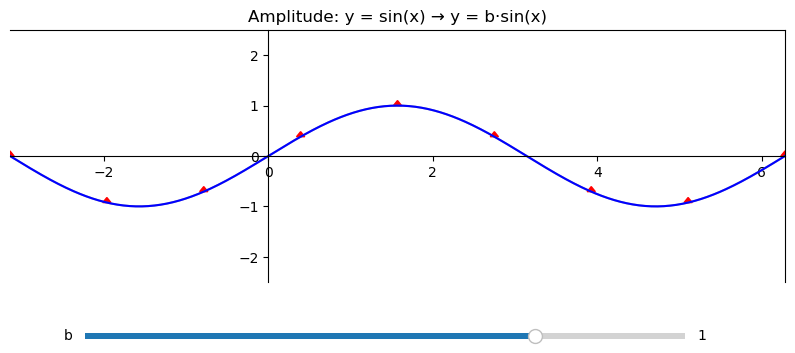

In [4]:
# amplitude.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

x = np.linspace(-np.pi, 2*np.pi, 500)
b0 = 1

fig, ax = plt.subplots(figsize=(10, 4))
plt.subplots_adjust(bottom=0.25)
ax.set_xlim(-np.pi, 2*np.pi)
ax.set_ylim(-2.5, 2.5)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_title("Amplitude: y = sin(x) → y = b·sin(x)")

sin_line, = ax.plot(x, np.sin(x), color='gray', alpha=0.6)
trans_line, = ax.plot(x, b0 * np.sin(x), color='blue')
arrows = []

def draw_arrows(b):
    global arrows
    for arrow in arrows:
        arrow.remove()
    arrows = []
    for xi in np.linspace(-np.pi, 2*np.pi, 9):
        y1 = np.sin(xi)
        y2 = b * y1
        arrows.append(ax.arrow(xi, y1, 0, y2 - y1, head_width=0.1, head_length=0.1, fc='red', ec='red'))

draw_arrows(b0)

ax_b = plt.axes([0.2, 0.1, 0.6, 0.03])
s_b = Slider(ax_b, 'b', -2, 2, valinit=b0)

def update(val):
    b = s_b.val
    trans_line.set_ydata(b * np.sin(x))
    draw_arrows(b)
    fig.canvas.draw_idle()

s_b.on_changed(update)
plt.show()


### 4.2.3 De hoeksnelheid; c

De grafiek heeft ook een periode. Bij de standaard grafiek is dit 2 pi. Stel dat ik een periode wil van 1 moet ik dus de x-waarde verkleinen met 2pi ofwel vergrooten met (1/2pi). Dit noemen we weer vermenigvuldigen t.o.v. de y-as. De waarde van x worden vermenigvuligd t.o.v. d y-as. Voor een sinus met periode 1 doen we dus sin(x)--> verm t.o.v. de y-as met 1/2pi en krijgen we sin(1/(1/2pi) *x) ofwel sin(2pi x). Dit is logisch, bij V t.o.v. de x-as vermenigvuldigen we de vergroting met y, en het tegeonversgesteld is dus V t.o.v. de y as. Dus dan Delen we de vergroting met x. Stel dat ik nou een periode T wil voor de standaard sinus grafiek. De vergrotingsfactor=nieuw/oud=T/2pi. Bij de transformatie krijgen we sin(x)--> V t.o.v.de y-as met T/2pi --> sin(x/(T/2pi))=sin((2pi/T)x)=sin(cx) met c=2pi/T. Dit principe is zichtbaar in het figuur hieronder. C is dus de volledige hoek per periode, daarom noemen we dat de hoeksnelheid.

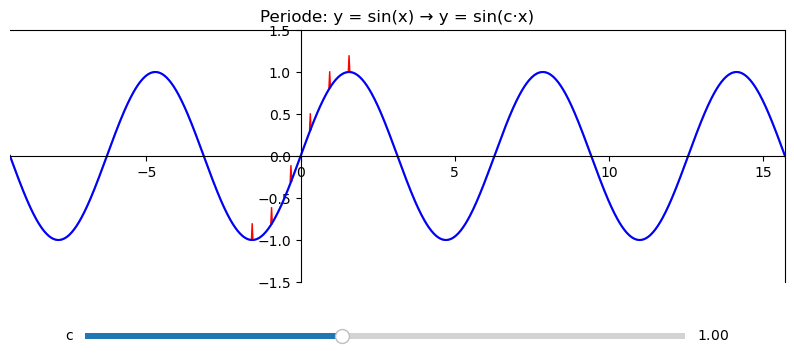

In [3]:
# periode.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

x = np.linspace(-3*np.pi, 5*np.pi, 1000)
c0 = 1

fig, ax = plt.subplots(figsize=(10, 4))
plt.subplots_adjust(bottom=0.25)
ax.set_xlim(-3*np.pi, 5*np.pi)
ax.set_ylim(-1.5, 1.5)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_title("Periode: y = sin(x) → y = sin(c·x)")

sin_line, = ax.plot(x, np.sin(x), color='gray', alpha=0.6)
trans_line, = ax.plot(x, np.sin(c0 * x), color='blue')
arrows = []

def draw_arrows(c):
    global arrows
    for arrow in arrows:
        arrow.remove()
    arrows = []
    x_samples = np.linspace(-0.5*np.pi, 0.5*np.pi, 6)
    for xi in x_samples:
        y = np.sin(xi)
        x_orig = xi / c
        dx = xi - x_orig
        arrows.append(ax.arrow(x_orig, y, dx, 0, head_width=0.05, head_length=0.2, fc='red', ec='red'))

draw_arrows(c0)

ax_c = plt.axes([0.2, 0.1, 0.6, 0.03])
s_c = Slider(ax_c, 'c', 0.25, 2, valinit=c0)

def update(val):
    c = s_c.val
    trans_line.set_ydata(np.sin(c * x))
    draw_arrows(c)
    fig.canvas.draw_idle()

s_c.on_changed(update)
plt.show()


### 4.2.4 De faseverschuiving; d

Als laatst hebben we de verplaatsing van het startpunt. Wanneer het startpunt wordt verschoven wordt in de eenheidscirkel de starthoek verschoven. De grafiek is periodiek, een andere startpunt is dus een andere fase. Daarom noemen we het een faseverschuiving. Stel dat ik op x=3 het start punt wil hebben denk ik; het starpunt normaal staat op y=sin(0), als ik die y waarde voor een andere x wil hebben moet ik dus hetzelfde tussen de haakjes hebben voor x=3. voor y=sin(x-3) is dat het geval want f(3)=sin(3-3)=sin(0) komen we dus op hetzelfde start punt uit. Horizontale translatie is weer het tegenovergestelde van verticale translatie. I.p.v. bij y de waarde op te tellen gaan we nu bij x de waarde aftrekken.

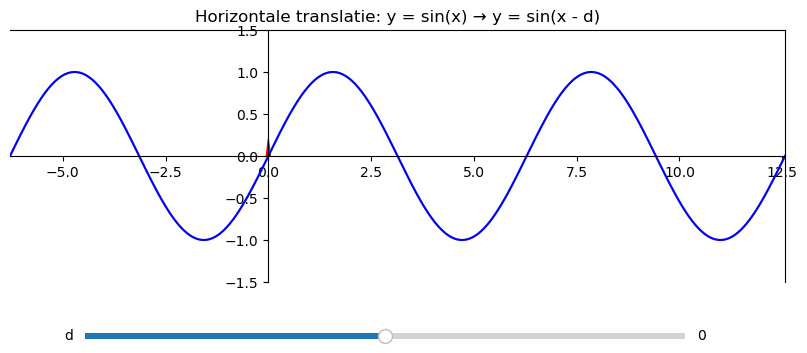

In [8]:
# horizontale_translatie.py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

x = np.linspace(-2*np.pi, 4*np.pi, 1000)
d0 = 0

fig, ax = plt.subplots(figsize=(10, 4))
plt.subplots_adjust(bottom=0.25)
ax.set_xlim(-2*np.pi, 4*np.pi)
ax.set_ylim(-1.5, 1.5)
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_title("Horizontale translatie: y = sin(x) → y = sin(x - d)")

sin_line, = ax.plot(x, np.sin(x), color='gray', alpha=0.6)
trans_line, = ax.plot(x, np.sin(x - d0), color='blue')
arrow = ax.arrow(0, 0, d0, 0, head_width=0.1, head_length=0.2, fc='red', ec='red')

ax_d = plt.axes([0.2, 0.1, 0.6, 0.03])
s_d = Slider(ax_d, 'd', -5, 5, valinit=d0)

def update(val):
    global arrow
    d = s_d.val
    trans_line.set_ydata(np.sin(x - d))
    arrow.remove()
    arrow = ax.arrow(0, 0, d, 0, head_width=0.1, head_length=0.2, fc='red', ec='red')
    fig.canvas.draw_idle()

s_d.on_changed(update)
plt.show()
